In [1]:
# ============================================
# Import Required Libraries
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


plt.style.use('ggplot')
plt.rcParams["figure.figsize"] = (10,6)

print("Libraries Imported Successfully")

Libraries Imported Successfully


# Load the Datasets

In [2]:
# ============================================
# Load Datasets
# ============================================

customers = pd.read_csv("../Dataset/customers.csv")
products = pd.read_csv("../Dataset/products.csv")
sales = pd.read_csv("../Dataset/sales.csv")

print("Customers :", customers.shape)
print("Products  :", products.shape)
print("Sales     :", sales.shape)

Customers : (5000, 7)
Products  : (495, 5)
Sales     : (50000, 9)


# Preview the Data

In [3]:
print("Customers")
display(customers.head())

print("Products")
display(products.head())

print("Sales")
display(sales.head())

Customers


,CustomerID,CustomerName,Gender,Age,City,State,Region
0,C00001,Aarav Yadav,Female,33,Mumbai,Maharashtra,West
1,C00002,Aryan Yadav,Male,61,Hyderabad,Telangana,South
2,C00003,Aditya Nair,Female,20,Lucknow,Uttar Pradesh,North
3,C00004,Aditya Singh,Male,50,Delhi,Delhi,North
4,C00005,Aarav Mehta,Male,63,Guwahati,Assam,East


Products


,ProductID,ProductName,Category,SubCategory,UnitCost
0,P0001,Laptop 1,Electronics,Laptop,1077
1,P0002,Laptop 2,Electronics,Laptop,285
2,P0003,Laptop 3,Electronics,Laptop,3971
3,P0004,Laptop 4,Electronics,Laptop,1463
4,P0005,Laptop 5,Electronics,Laptop,4672


Sales


,OrderID,OrderDate,CustomerID,ProductID,Quantity,UnitPrice,Discount,Sales,Profit
0,O000001,2024-07-13,C01502,P0154,4,4200.18,0.20,13440.58,3992.58
1,O000002,2024-03-04,C00933,P0355,4,1363.26,0.00,5453.04,1669.04
2,O000003,2023-01-23,C00007,P0224,4,3956.03,0.15,13450.50,5518.50
3,O000004,2024-11-12,C04219,P0308,2,4924.17,0.00,9848.34,1878.34
4,O000005,2024-09-01,C03973,P0030,1,5364.16,0.05,5095.95,1848.95


# Data Information

In [4]:
print("CUSTOMERS")
customers.info()

print("\nPRODUCTS")
products.info()

print("\nSALES")
sales.info()

CUSTOMERS
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   CustomerID    5000 non-null   str  
 1   CustomerName  5000 non-null   str  
 2   Gender        5000 non-null   str  
 3   Age           5000 non-null   int64
 4   City          5000 non-null   str  
 5   State         5000 non-null   str  
 6   Region        5000 non-null   str  
dtypes: int64(1), str(6)
memory usage: 273.6 KB

PRODUCTS
<class 'pandas.DataFrame'>
RangeIndex: 495 entries, 0 to 494
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   ProductID    495 non-null    str  
 1   ProductName  495 non-null    str  
 2   Category     495 non-null    str  
 3   SubCategory  495 non-null    str  
 4   UnitCost     495 non-null    int64
dtypes: int64(1), str(4)
memory usage: 19.5 KB

SALES
<class 'pandas.DataFrame'>
RangeIndex: 50

# Check Missing Values and Duplicate Records

In [5]:
print("Missing Values")

display(customers.isnull().sum())

display(products.isnull().sum())

display(sales.isnull().sum())

print("\nDuplicate Records")

print("Customers :", customers.duplicated().sum())
print("Products  :", products.duplicated().sum())
print("Sales     :", sales.duplicated().sum())

Missing Values


CustomerID      0
CustomerName    0
Gender          0
Age             0
City            0
State           0
Region          0
dtype: int64

ProductID      0
ProductName    0
Category       0
SubCategory    0
UnitCost       0
dtype: int64

OrderID       0
OrderDate     0
CustomerID    0
ProductID     0
Quantity      0
UnitPrice     0
Discount      0
Sales         0
Profit        0
dtype: int64


Duplicate Records
Customers : 0
Products  : 0
Sales     : 0


# Merge the Three Tables

In [6]:
df = sales.merge(customers,on="CustomerID")
df = df.merge(products,on="ProductID")

print(df.shape)

display(df.head())

(50000, 19)


,OrderID,OrderDate,CustomerID,ProductID,Quantity,UnitPrice,Discount,Sales,Profit,CustomerName,Gender,Age,City,State,Region,ProductName,Category,SubCategory,UnitCost
0,O000001,2024-07-13,C01502,P0154,4,4200.18,0.20,13440.58,3992.58,Neha Patel,Female,63,Chennai,Tamil Nadu,South,Mouse 22,Electronics,Mouse,2362
1,O000002,2024-03-04,C00933,P0355,4,1363.26,0.00,5453.04,1669.04,Sneha Verma,Female,34,Kolkata,West Bengal,East,Notebook 25,Office Supplies,Notebook,946
2,O000003,2023-01-23,C00007,P0224,4,3956.03,0.15,13450.50,5518.50,Aarav Patel,Female,39,Chennai,Tamil Nadu,South,Table 26,Furniture,Table,1983
3,O000004,2024-11-12,C04219,P0308,2,4924.17,0.00,9848.34,1878.34,Ananya Sharma,Female,52,Hyderabad,Telangana,South,Cabinet 11,Furniture,Cabinet,3985
4,O000005,2024-09-01,C03973,P0030,1,5364.16,0.05,5095.95,1848.95,Sneha Yadav,Male,53,Kolkata,West Bengal,East,Laptop 30,Electronics,Laptop,3247


# Feature Engineering

In [7]:
df["OrderDate"] = pd.to_datetime(df["OrderDate"])

df["Year"] = df["OrderDate"].dt.year

df["Month"] = df["OrderDate"].dt.month

df["MonthName"] = df["OrderDate"].dt.month_name()

df["Quarter"] = df["OrderDate"].dt.quarter

df["Day"] = df["OrderDate"].dt.day

display(df.head())

,OrderID,OrderDate,CustomerID,ProductID,Quantity,UnitPrice,Discount,Sales,Profit,CustomerName,...,Region,ProductName,Category,SubCategory,UnitCost,Year,Month,MonthName,Quarter,Day
0,O000001,2024-07-13,C01502,P0154,4,4200.18,0.20,13440.58,3992.58,Neha Patel,...,South,Mouse 22,Electronics,Mouse,2362,2024,7,July,3,13
1,O000002,2024-03-04,C00933,P0355,4,1363.26,0.00,5453.04,1669.04,Sneha Verma,...,East,Notebook 25,Office Supplies,Notebook,946,2024,3,March,1,4
2,O000003,2023-01-23,C00007,P0224,4,3956.03,0.15,13450.50,5518.50,Aarav Patel,...,South,Table 26,Furniture,Table,1983,2023,1,January,1,23
3,O000004,2024-11-12,C04219,P0308,2,4924.17,0.00,9848.34,1878.34,Ananya Sharma,...,South,Cabinet 11,Furniture,Cabinet,3985,2024,11,November,4,12
4,O000005,2024-09-01,C03973,P0030,1,5364.16,0.05,5095.95,1848.95,Sneha Yadav,...,East,Laptop 30,Electronics,Laptop,3247,2024,9,September,3,1


# Summary Statistics

In [8]:
display(df.describe())

,OrderDate,Quantity,UnitPrice,Discount,Sales,Profit,Age,UnitCost,Year,Month,Quarter,Day
count,50000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000
mean,2023-12-29 19:16:14.015999,2.999400,4048.74778,0.100713,10916.080949,3340.285749,41.478260,2527.933840,2023.494780,6.520780,2.50842,15.673520
min,2023-01-01 00:00:00,1.000000,150.64000,0.000000,125.060000,-835.720000,18.000000,125.000000,2023.000000,1.000000,1.00000,1.000000
25%,2023-06-30 00:00:00,2.000000,2032.94750,0.050000,4012.040000,836.647500,29.000000,1305.000000,2023.000000,4.000000,2.00000,8.000000
50%,2023-12-28 00:00:00,3.000000,3969.97500,0.100000,8417.160000,2155.760000,41.000000,2528.000000,2023.000000,7.000000,3.00000,16.000000
75%,2024-06-29 00:00:00,4.000000,5917.61500,0.150000,16000.265000,4672.350000,54.000000,3778.000000,2024.000000,10.000000,4.00000,23.000000
max,2024-12-31 00:00:00,5.000000,9956.78000,0.200000,49315.400000,24430.400000,65.000000,4983.000000,2024.000000,12.000000,4.00000,31.000000
std,NaN,1.414199,2369.98135,0.070980,8805.876770,3474.643941,14.051702,1417.748158,0.499978,3.448276,1.11565,8.800461


# Business KPIs

In [9]:
total_sales = df["Sales"].sum()

total_profit = df["Profit"].sum()

total_orders = df["OrderID"].nunique()

total_customers = df["CustomerID"].nunique()

average_order = df["Sales"].mean()

print(f"Total Revenue        : ₹{total_sales:,.2f}")

print(f"Total Profit         : ₹{total_profit:,.2f}")

print(f"Total Orders         : {total_orders}")

print(f"Total Customers      : {total_customers}")

print(f"Average Order Value  : ₹{average_order:,.2f}")

Total Revenue        : ₹545,804,047.43
Total Profit         : ₹167,014,287.43
Total Orders         : 50000
Total Customers      : 5000
Average Order Value  : ₹10,916.08


# Create a Clean Dataset for Analysis

In [10]:
display(df.head())

print(df.columns)

,OrderID,OrderDate,CustomerID,ProductID,Quantity,UnitPrice,Discount,Sales,Profit,CustomerName,...,Region,ProductName,Category,SubCategory,UnitCost,Year,Month,MonthName,Quarter,Day
0,O000001,2024-07-13,C01502,P0154,4,4200.18,0.20,13440.58,3992.58,Neha Patel,...,South,Mouse 22,Electronics,Mouse,2362,2024,7,July,3,13
1,O000002,2024-03-04,C00933,P0355,4,1363.26,0.00,5453.04,1669.04,Sneha Verma,...,East,Notebook 25,Office Supplies,Notebook,946,2024,3,March,1,4
2,O000003,2023-01-23,C00007,P0224,4,3956.03,0.15,13450.50,5518.50,Aarav Patel,...,South,Table 26,Furniture,Table,1983,2023,1,January,1,23
3,O000004,2024-11-12,C04219,P0308,2,4924.17,0.00,9848.34,1878.34,Ananya Sharma,...,South,Cabinet 11,Furniture,Cabinet,3985,2024,11,November,4,12
4,O000005,2024-09-01,C03973,P0030,1,5364.16,0.05,5095.95,1848.95,Sneha Yadav,...,East,Laptop 30,Electronics,Laptop,3247,2024,9,September,3,1


Index(['OrderID', 'OrderDate', 'CustomerID', 'ProductID', 'Quantity',
       'UnitPrice', 'Discount', 'Sales', 'Profit', 'CustomerName', 'Gender',
       'Age', 'City', 'State', 'Region', 'ProductName', 'Category',
       'SubCategory', 'UnitCost', 'Year', 'Month', 'MonthName', 'Quarter',
       'Day'],
      dtype='str')


# KPI Dashboard



In [11]:


kpi = pd.DataFrame({
    "Metric":[
        "Total Revenue",
        "Total Profit",
        "Total Orders",
        "Total Customers",
        "Average Order Value"
    ],

    "Value":[
        f"₹{df['Sales'].sum():,.2f}",
        f"₹{df['Profit'].sum():,.2f}",
        df['OrderID'].nunique(),
        df['CustomerID'].nunique(),
        f"₹{df['Sales'].mean():,.2f}"
    ]
})

display(kpi)

,Metric,Value
0,Total Revenue,"₹545,804,047.43"
1,Total Profit,"₹167,014,287.43"
2,Total Orders,50000
3,Total Customers,5000
4,Average Order Value,"₹10,916.08"


## Monthly Sales Trend



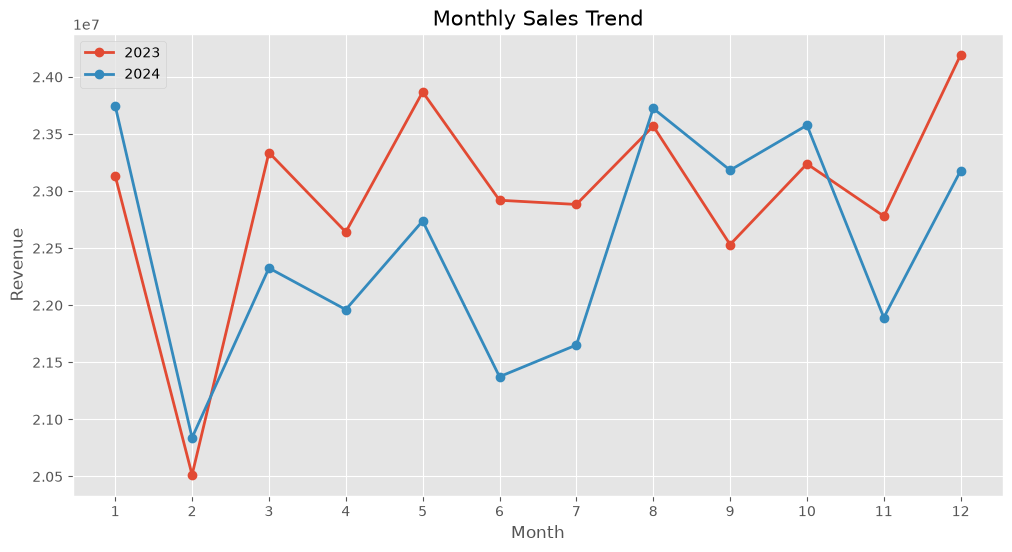

In [12]:
monthly_sales = (
    df.groupby(["Year","Month"])["Sales"]
      .sum()
      .reset_index()
)

plt.figure(figsize=(12,6))

for year in monthly_sales["Year"].unique():

    temp = monthly_sales[monthly_sales["Year"]==year]

    plt.plot(
        temp["Month"],
        temp["Sales"],
        marker="o",
        linewidth=2,
        label=str(year)
    )

plt.title("Monthly Sales Trend",fontsize=15)

plt.xlabel("Month")

plt.ylabel("Revenue")

plt.xticks(range(1,13))

plt.grid(True)

plt.legend()

plt.show()

### Business Insight


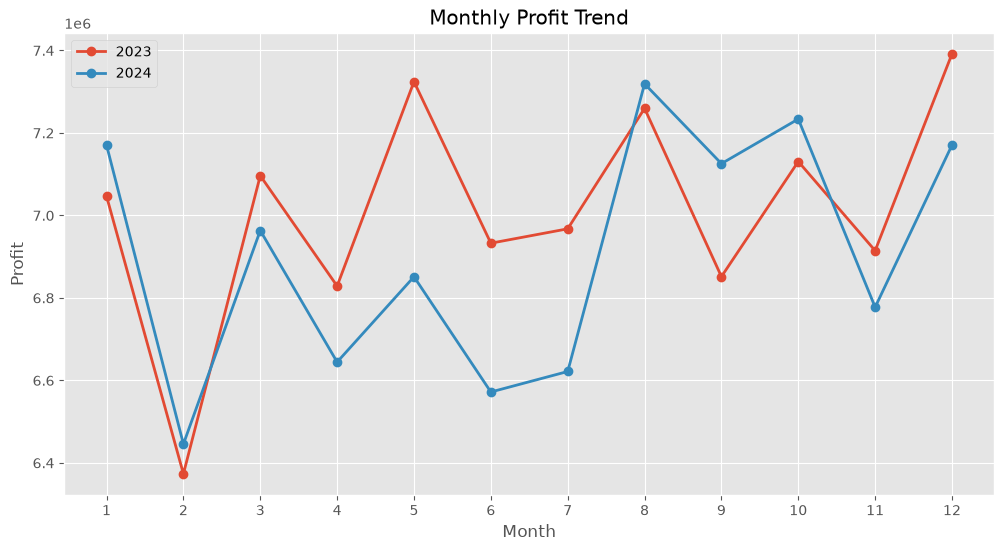

In [13]:
monthly_profit = (
    df.groupby(["Year","Month"])["Profit"]
      .sum()
      .reset_index()
)

plt.figure(figsize=(12,6))

for year in monthly_profit["Year"].unique():

    temp = monthly_profit[monthly_profit["Year"]==year]

    plt.plot(
        temp["Month"],
        temp["Profit"],
        marker="o",
        linewidth=2,
        label=str(year)
    )

plt.title("Monthly Profit Trend")

plt.xlabel("Month")

plt.ylabel("Profit")

plt.xticks(range(1,13))

plt.legend()

plt.grid(True)

plt.show()

## Sales by Category

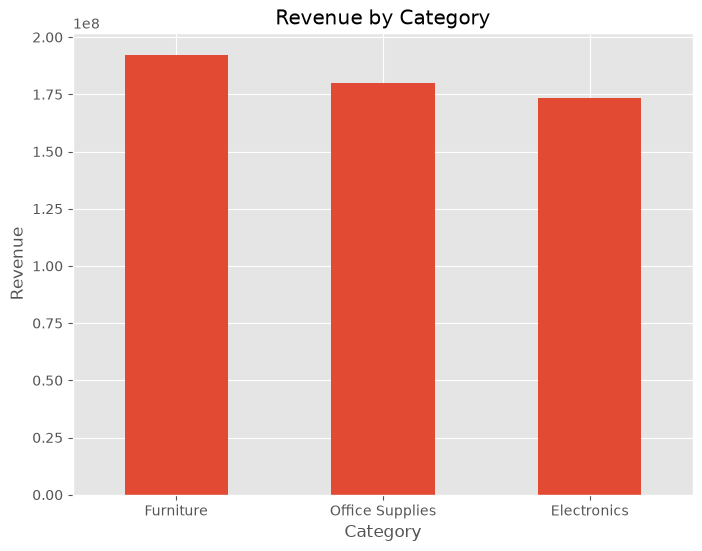

In [14]:
category_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,6))

category_sales.plot(kind="bar")

plt.title("Revenue by Category")

plt.xlabel("Category")

plt.ylabel("Revenue")

plt.xticks(rotation=0)

plt.show()

### Business Insight

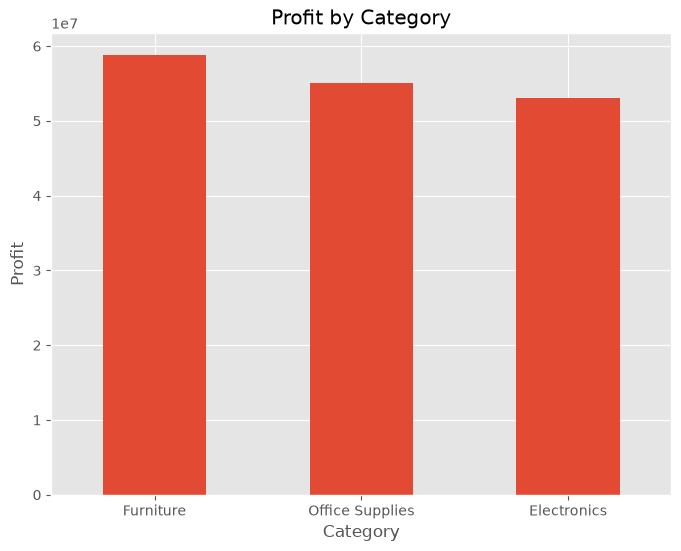

In [15]:
category_profit = (
    df.groupby("Category")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,6))

category_profit.plot(kind="bar")

plt.title("Profit by Category")

plt.xlabel("Category")

plt.ylabel("Profit")

plt.xticks(rotation=0)

plt.show()

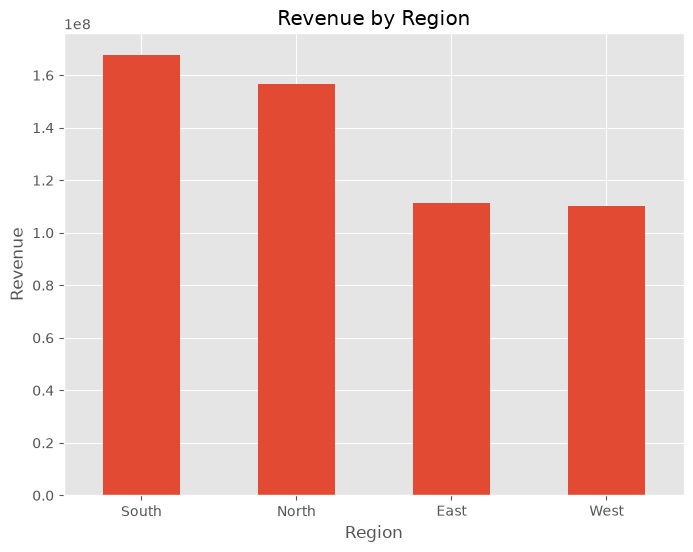

In [16]:
region_sales = (
    df.groupby("Region")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,6))

region_sales.plot(kind="bar")

plt.title("Revenue by Region")

plt.xlabel("Region")

plt.ylabel("Revenue")

plt.xticks(rotation=0)

plt.show()

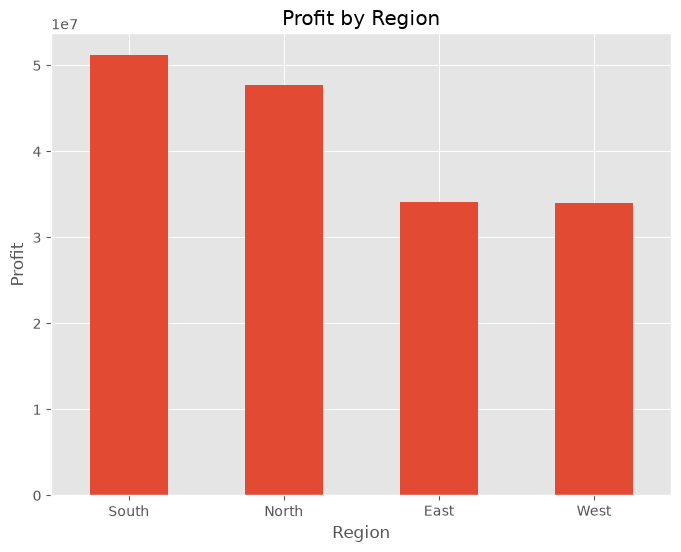

In [17]:
region_profit = (
    df.groupby("Region")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,6))

region_profit.plot(kind="bar")

plt.title("Profit by Region")

plt.xlabel("Region")

plt.ylabel("Profit")

plt.xticks(rotation=0)

plt.show()

## Top 10 Customers by Revenue



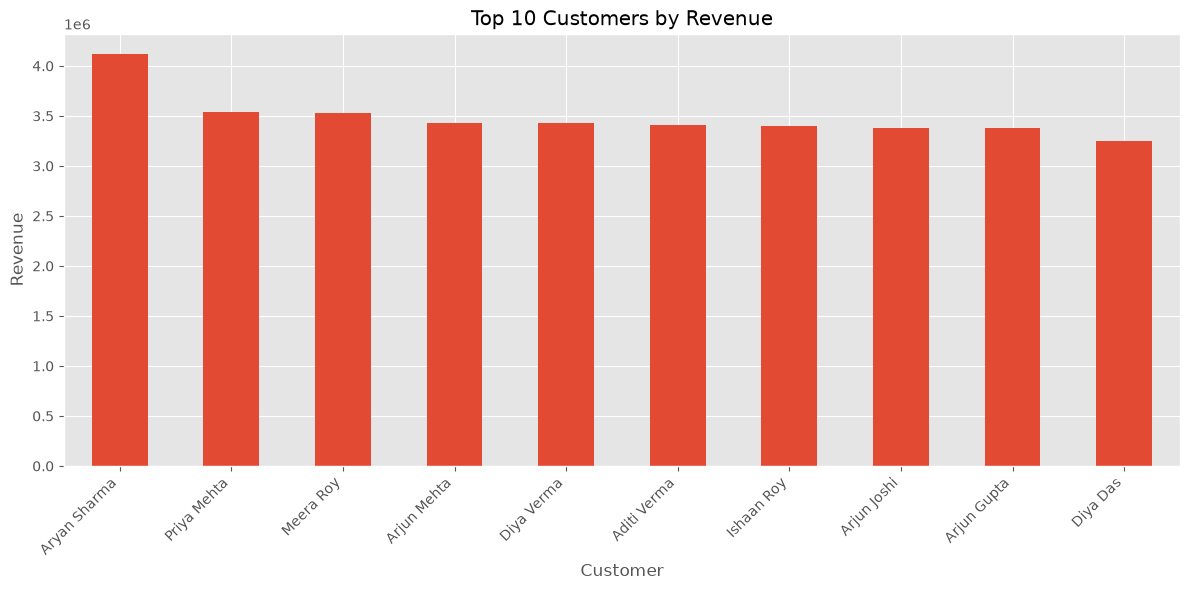

In [18]:
top_customers = (
    df.groupby("CustomerName")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))
top_customers.plot(kind="bar")
plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer")
plt.ylabel("Revenue")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Top 10 Products by Revenue


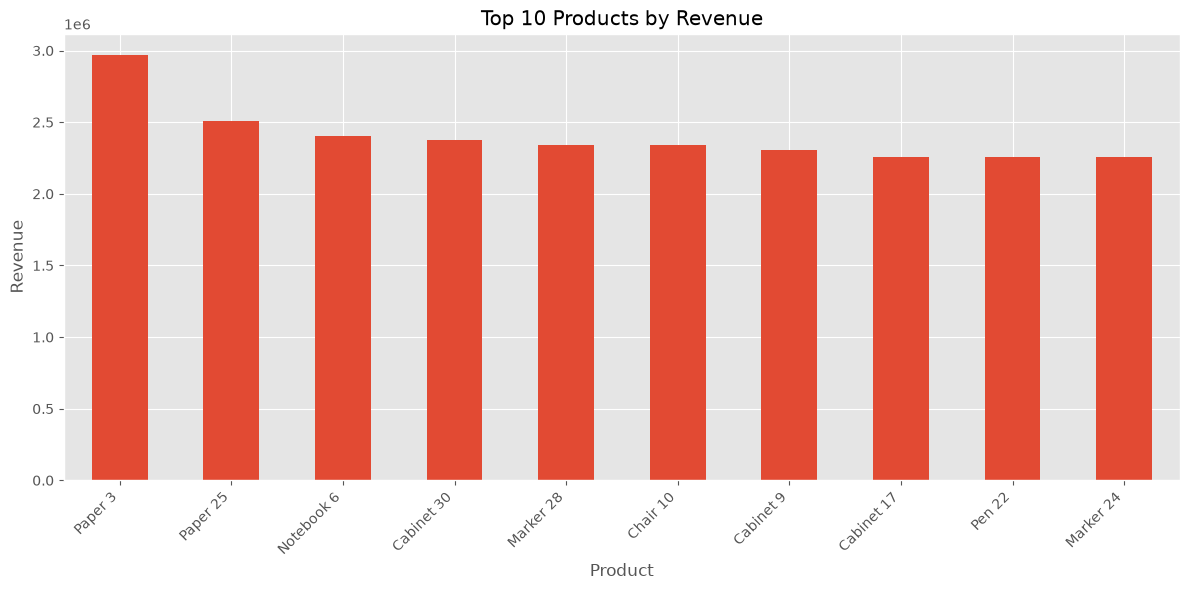

In [19]:
top_products = (
    df.groupby("ProductName")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))
top_products.plot(kind="bar")
plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Bottom 10 Products by Revenue

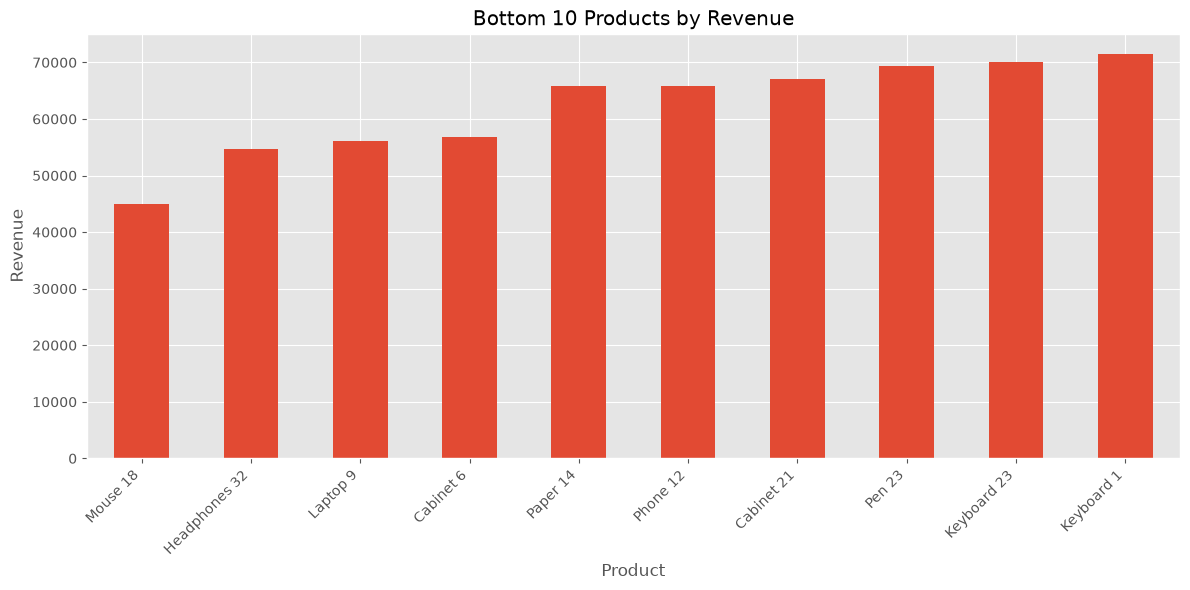

In [20]:
bottom_products = (
    df.groupby("ProductName")["Sales"]
      .sum()
      .sort_values()
      .head(10)
)

plt.figure(figsize=(12,6))
bottom_products.plot(kind="bar")
plt.title("Bottom 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Business Insight



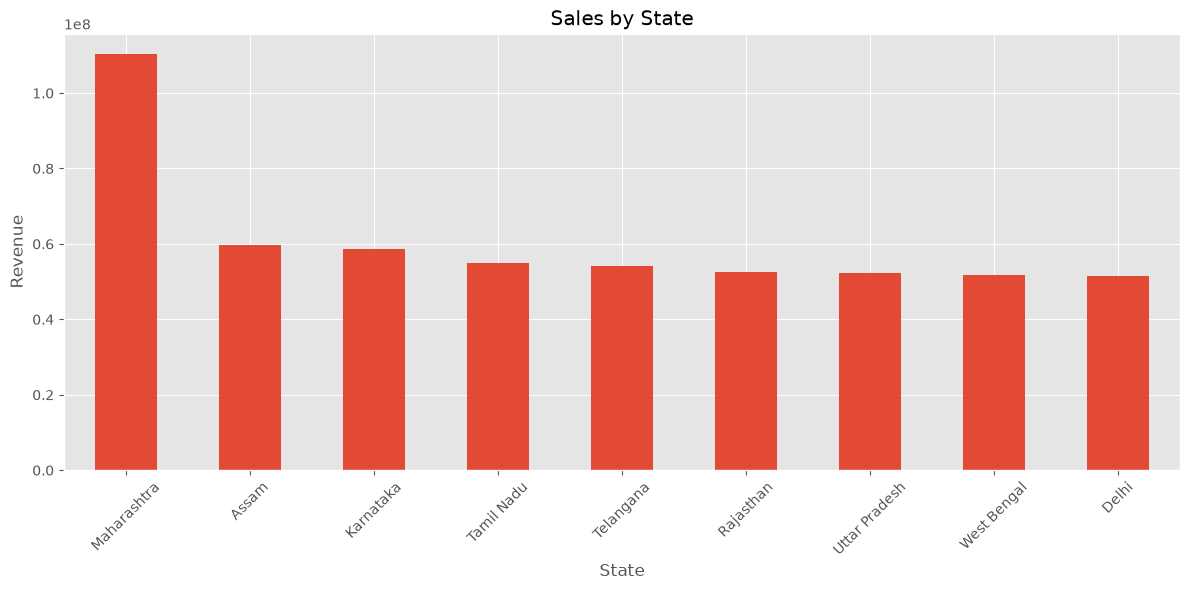

In [21]:
state_sales = (
    df.groupby("State")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))
state_sales.plot(kind="bar")
plt.title("Sales by State")
plt.xlabel("State")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

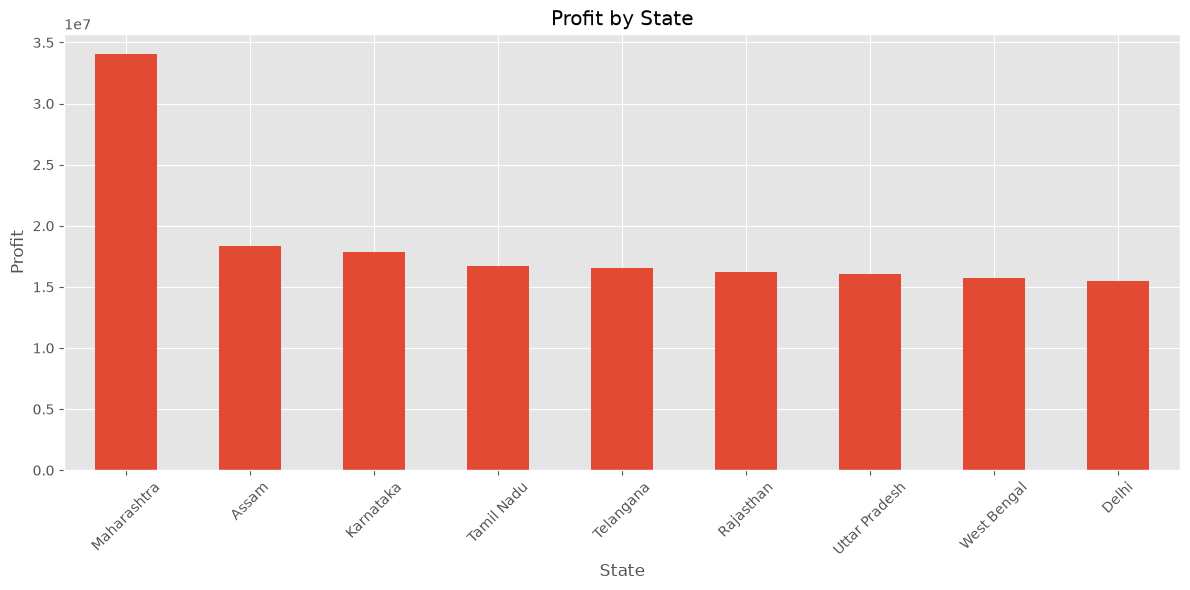

In [22]:
state_profit = (
    df.groupby("State")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))
state_profit.plot(kind="bar")
plt.title("Profit by State")
plt.xlabel("State")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

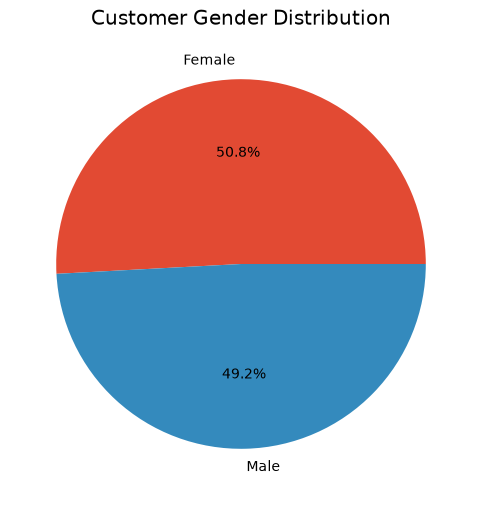

In [23]:
gender_counts = df["Gender"].value_counts()

plt.figure(figsize=(6,6))
gender_counts.plot(kind="pie", autopct="%1.1f%%")
plt.title("Customer Gender Distribution")
plt.ylabel("")
plt.show()

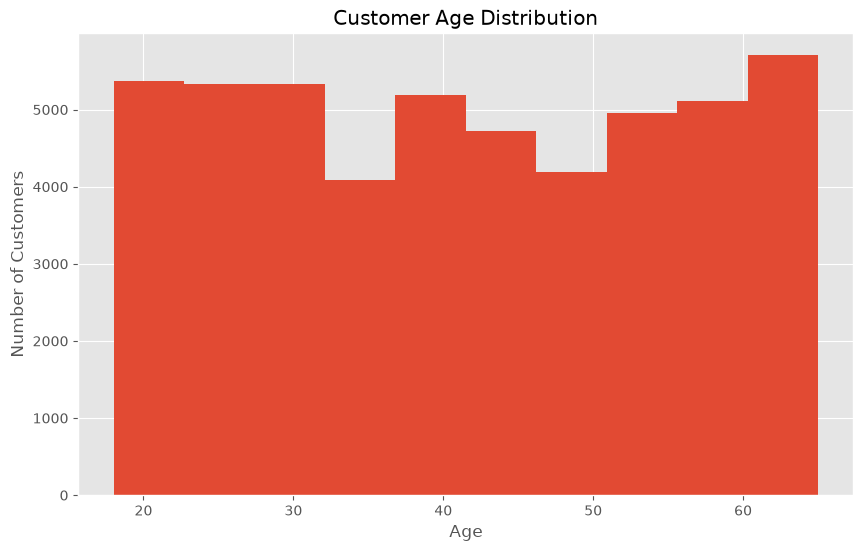

In [24]:
plt.figure(figsize=(10,6))
plt.hist(df["Age"], bins=10)
plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

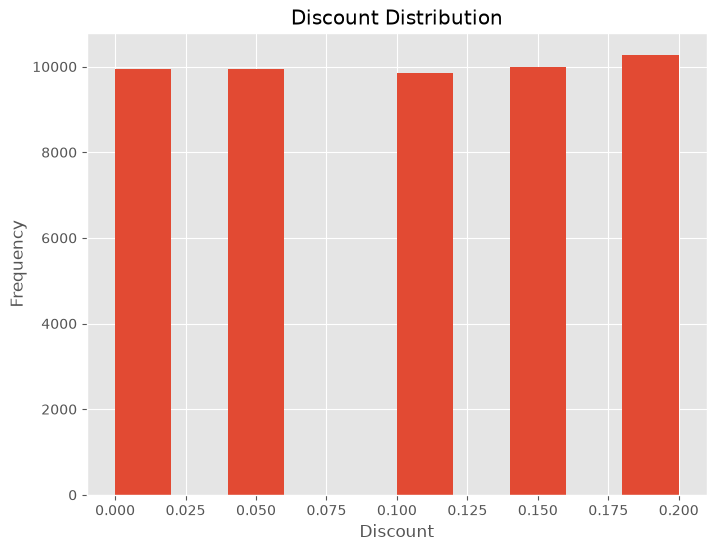

In [25]:
plt.figure(figsize=(8,6))
plt.hist(df["Discount"], bins=10)
plt.title("Discount Distribution")
plt.xlabel("Discount")
plt.ylabel("Frequency")
plt.show()

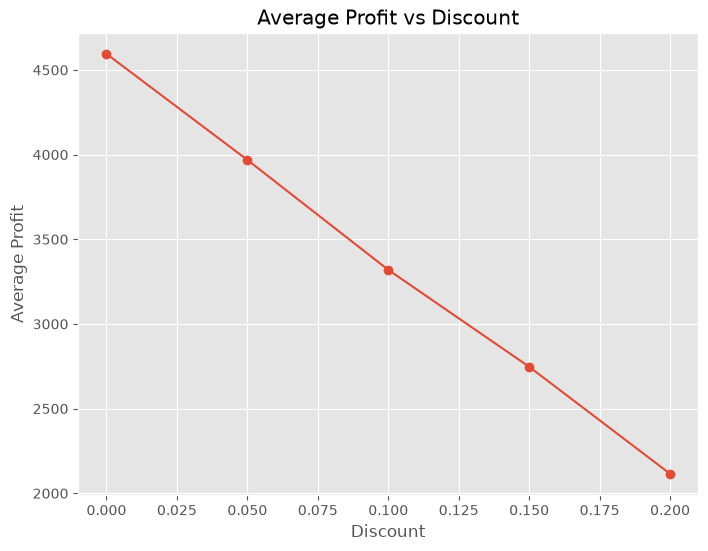

In [26]:
discount_profit = (
    df.groupby("Discount")["Profit"]
      .mean()
)

plt.figure(figsize=(8,6))
discount_profit.plot(marker="o")
plt.title("Average Profit vs Discount")
plt.xlabel("Discount")
plt.ylabel("Average Profit")
plt.grid(True)
plt.show()

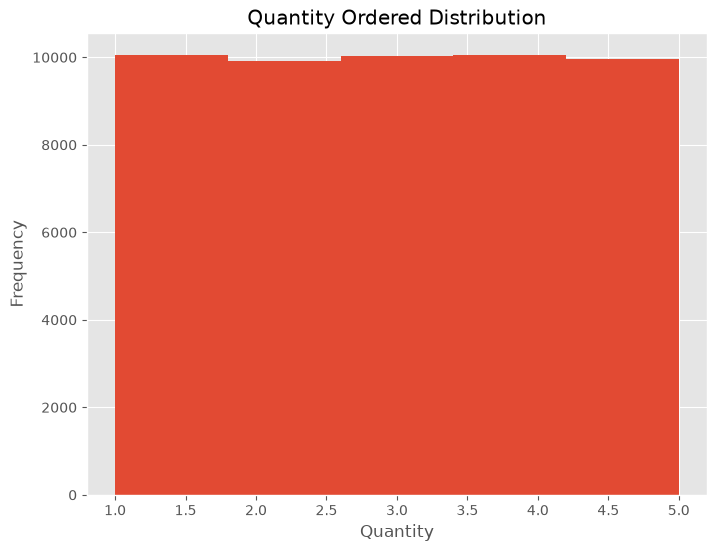

In [27]:
plt.figure(figsize=(8,6))
plt.hist(df["Quantity"], bins=5)
plt.title("Quantity Ordered Distribution")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.show()

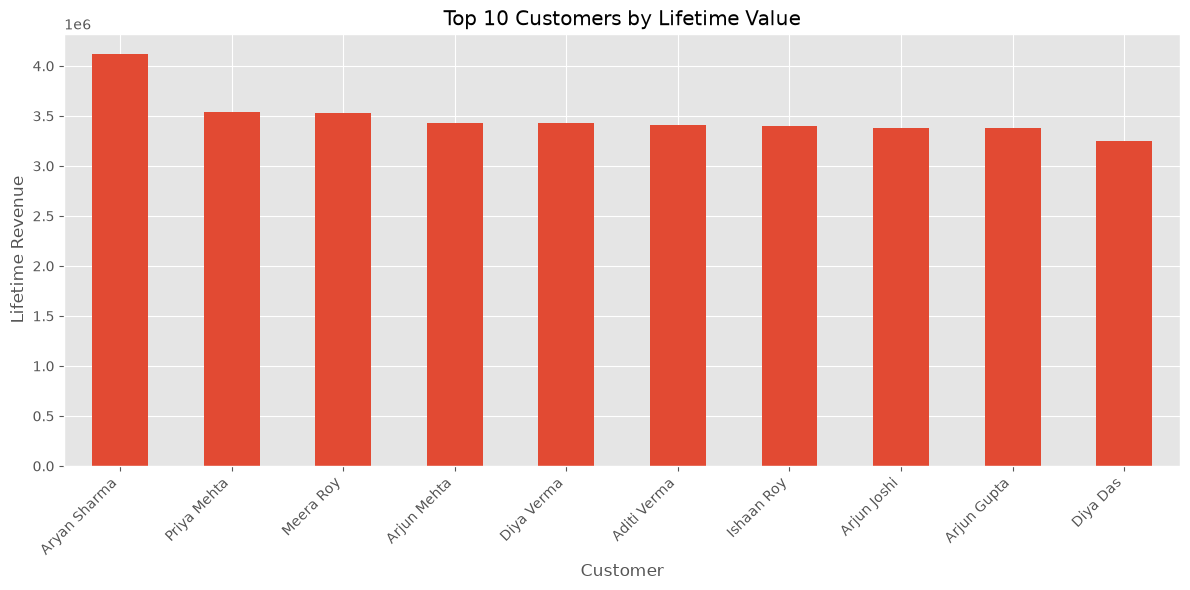

In [28]:
clv = (
    df.groupby("CustomerName")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))
clv.plot(kind="bar")
plt.title("Top 10 Customers by Lifetime Value")
plt.xlabel("Customer")
plt.ylabel("Lifetime Revenue")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()